Exploratory Data Analysis

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ID = 'rba-pipeline-494410'
client = bigquery.Client(project=PROJECT_ID)

query = f'SELECT * FROM `{PROJECT_ID}.gold.mart_australia_rates` ORDER BY date'
df = client.query(query).to_dataframe()

c:\Users\User\OneDrive\Documents\Data storage\python\scripts\venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [ ]:
df.shape

(119, 7)

In [4]:
df.head(10)

,countryiso3code,date,value,indicator_id,indicator_name,country_id,country_name
0,AUS,1960,5.000000,FR.INR.LEND,Lending interest rate (%),AU,Australia
1,AUS,1961,2.208047,FR.INR.RINR,Real interest rate (%),AU,Australia
2,AUS,1961,5.500000,FR.INR.LEND,Lending interest rate (%),AU,Australia
3,AUS,1962,5.578598,FR.INR.RINR,Real interest rate (%),AU,Australia
4,AUS,1962,5.500000,FR.INR.LEND,Lending interest rate (%),AU,Australia
5,AUS,1963,5.125000,FR.INR.LEND,Lending interest rate (%),AU,Australia
6,AUS,1963,3.275698,FR.INR.RINR,Real interest rate (%),AU,Australia
7,AUS,1964,1.735486,FR.INR.RINR,Real interest rate (%),AU,Australia
8,AUS,1964,5.072917,FR.INR.LEND,Lending interest rate (%),AU,Australia
9,AUS,1965,5.312500,FR.INR.LEND,Lending interest rate (%),AU,Australia


In [10]:
df_wide = df.pivot(index='date', columns='indicator_id', values='value').reset_index()
df_wide.head()

indicator_id,date,FR.INR.LEND,FR.INR.RINR
0,1960,5.000000,NaN
1,1961,5.500000,2.208047
2,1962,5.500000,5.578598
3,1963,5.125000,3.275698
4,1964,5.072917,1.735486


In [16]:
df_wide = df_wide.rename(columns={
    'FR.INR.LEND': 'lending_rate',
    'FR.INR.RINR': 'real_interest_rate'
})
df_wide.head()

indicator_id,date,lending_rate,real_interest_rate
0,1960,5.000000,NaN
1,1961,5.500000,2.208047
2,1962,5.500000,5.578598
3,1963,5.125000,3.275698
4,1964,5.072917,1.735486


<Axes: xlabel='date'>

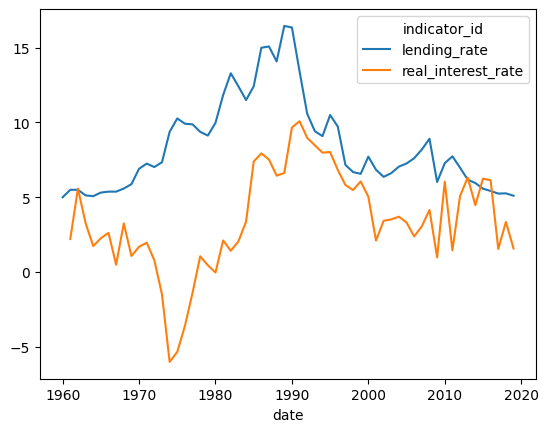

In [19]:
df_wide.plot(x='date', y=['lending_rate', 'real_interest_rate'])

In [21]:
df_wide['lending_rate_change'] = df_wide['lending_rate'].diff()
df_wide.head()

indicator_id,date,lending_rate,real_interest_rate,lending_rate_change
0,1960,5.000000,NaN,NaN
1,1961,5.500000,2.208047,0.500000
2,1962,5.500000,5.578598,0.000000
3,1963,5.125000,3.275698,-0.375000
4,1964,5.072917,1.735486,-0.052083


In [28]:
def label_direction(x):
    if pd.isna(x):
        return None
    elif x > 0:
        return 'up'
    else: 
        return 'down'
        
    
df_wide['direction'] = df_wide['lending_rate_change'].apply(label_direction)
df_wide['direction'].value_counts()

direction
down    31
up      28
Name: count, dtype: int64

In [29]:
df_wide.describe()

indicator_id,date,lending_rate,real_interest_rate,lending_rate_change
count,60.0,60.000000,59.000000,59.000000
mean,1989.5,8.417449,3.502883,0.001712
std,17.464249,3.096455,3.406971,1.114937
min,1960.0,5.000000,-6.013191,-2.937500
25%,1974.75,5.931250,1.556414,-0.427083
50%,1989.5,7.268750,3.306806,0.000000
75%,2004.25,9.932292,6.095805,0.479167
max,2019.0,16.458333,10.086471,2.583333
